In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv("/content/cleaned_data (1).csv")

In [6]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,5,2010,WD,Normal,215000.0
1,2,526350040,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,...,0,0,120,0,0,6,2010,WD,Normal,105000.0
2,3,526351010,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,...,0,0,0,0,12500,6,2010,WD,Normal,172000.0
3,4,526353030,20,RL,93.0,11160,Pave,Reg,Lvl,AllPub,...,0,0,0,0,0,4,2010,WD,Normal,244000.0
4,5,527105010,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,3,2010,WD,Normal,189900.0


In [7]:
#One-hot encode
df=pd.get_dummies(df,columns=["MS Zoning"])
df=pd.get_dummies(df,columns=["Sale Condition"])

i used one hot encoding to convert from categorical to numeric so that the model can understand

In [8]:
#Ordinal encode
ordered_col=pd.CategoricalDtype(categories=["No","Mn","Av","Gd"], ordered=True)
df["Bsmt Exposure_ord"] = df["Bsmt Exposure"].astype(ordered_col).cat.codes

i used ordinal encoding for the colunm "Bsmt Exposure" because it is natural order

In [9]:
#Scale
from sklearn.preprocessing import StandardScaler
def train_test_split(data):
  split = int(len(data)*0.8)
  return data[:split],data[split:]

train, test =train_test_split(df)

train=train.copy()
test=test.copy()

scaler=StandardScaler()

train[["Gr Liv Area_std", "Total Bsmt SF_std"]] = scaler.fit_transform(train[["Gr Liv Area", "Total Bsmt SF"]])
test[["Gr Liv Area_std", "Total Bsmt SF_std"]] = scaler.transform(test[["Gr Liv Area", "Total Bsmt SF"]])


i used StandardScaler to improve performance of models by make the mean=0 and standard diviation=1

In [10]:
#domain features
df["price_per_sqft"]=df["SalePrice"] / df["Gr Liv Area"].replace(0,np.nan)
df["Area_per_Room"]=df["TotRms AbvGrd"] / df["Gr Liv Area"].replace(0,np.nan)


["price_per_sqft"] is useful because it is become eseier for the model to analys(normalized price feature)

["Area_per_Room"] is useful because the model can easely compare between different houses (by their total size)


In [11]:
#interaction feature
df["quality_x_area"]=df["Overall Qual"] * df["Gr Liv Area"]

["quality_x_area"] is useful because it is contain two featuers into one featuer

In [12]:
# Log-transform
df["SalePrice_log1p"]=np.log1p(df["SalePrice"])

i used Log-transform to reduse skewness on SalePrice colunm and large values become more normally

Text(0.5, 1.0, 'SalePrice log1p')

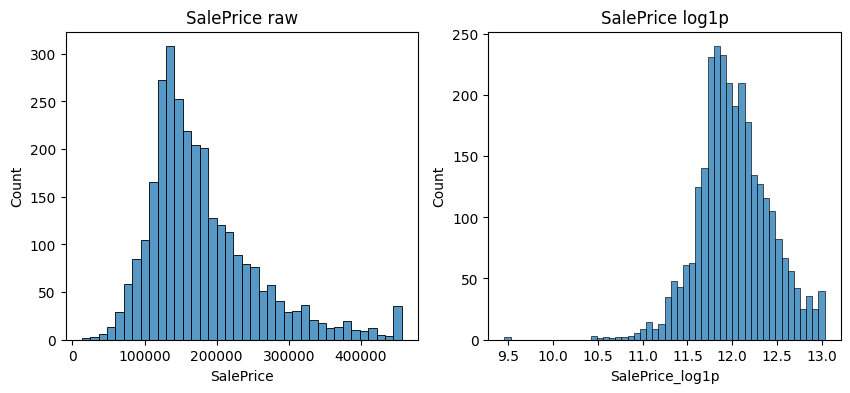

In [13]:
#histogram before and after Log-transform
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df["SalePrice"], ax=axes[0]); axes[0].set_title("SalePrice raw")
sns.histplot(df["SalePrice_log1p"], ax=axes[1]); axes[1].set_title("SalePrice log1p")

The raw SalePrice is right-skewed with a long tail.  
After applying log1p, the distribution becomes more symmetric and closer to normal.


In [14]:
#Binning
bins=[1900, 1950, 1980, 2000, 2026]
labels=["very old","old","recent","new"]
df["Year Built_group"]=pd.cut(df["Year Built"],bins=bins,labels=labels,right=False)

i made bins to help reduse noise and to make patterns easier models to detect.

In [15]:
#Remove redundant features
def drop_correlated_features(df, threshold=0.95):
  corr_matrix = df.corr().abs()
  upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
  to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
  return df.drop(columns=to_drop), to_drop
df,drop_cols=drop_correlated_features(df.select_dtypes(include=["number"]))

we Remove redundant features to avoid duplicate information that may be complex for the model wich is going to reduce model's performance